In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.optimize
import seaborn as sns
import os

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator,NullFormatter,LogLocator)
majorFormatter = FormatStrFormatter('%d')

from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=10)

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [24]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256]
p_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cases = 100

nullity_evolution = []
braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_variance_time = np.zeros((len(L_list), len(p_list)))

for ii, L in enumerate(L_list):
    nullity_evolution.append([])

    for jj, p in enumerate(p_list):

        values = []
        count = 0
        for case in range(cases):
            filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results_p'+str("%.2f"%p)+f'_L{L}_init_state_random_case{case}.pkl'
            with open(filename, 'rb') as f:
                data = pickle.load(f)
            count += 1

            braidification_time[ii,jj] += len(data['nullity_evolution'])
            values.append(len(data['nullity_evolution']))
            
            if count == 1:
                nullity_evolution[ii].append(np.array(data['nullity_evolution'], float))
                Tmax = len(data['nullity_evolution'])
            else:
                T = len(data['nullity_evolution'])
                if T > Tmax:
                    nulev = np.zeros(T)
                    nulev[:Tmax] = nullity_evolution[ii][jj]
                    nullity_evolution[ii][jj] = nulev + np.array(data['nullity_evolution'], float)
                    Tmax = T
                else:
                    nulev = np.zeros(Tmax)
                    nulev[:T] = np.array(data['nullity_evolution'], float)
                    nullity_evolution[ii][jj] += nulev
        print(p, L, values, np.std(values), np.mean(values))            
        braidification_variance_time[ii,jj] = np.std(values)
            
        nullity_evolution[ii][jj] /= count
        print(braidification_time[ii,jj]/count)
braidification_time /= cases

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['nullity_evolution'] = nullity_evolution  
data['braidification_time'] = braidification_time  
data['braidification_time_variance'] = braidification_variance_time  


filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

0.1 16 [31, 101, 103, 24, 36, 90, 32, 52, 51, 68, 66, 38, 82, 74, 92, 41, 68, 46, 38, 21, 20, 23, 25, 112, 70, 47, 46, 32, 11, 27, 58, 72, 37, 67, 63, 75, 63, 31, 61, 78, 24, 81, 39, 32, 54, 30, 26, 29, 46, 88, 39, 42, 35, 40, 34, 48, 59, 36, 61, 31, 57, 69, 92, 148, 42, 31, 41, 23, 60, 34, 64, 19, 88, 73, 66, 39, 106, 59, 52, 23, 53, 42, 38, 42, 118, 79, 60, 43, 47, 43, 44, 36, 54, 48, 25, 28, 98, 44, 42, 71] 25.0725567104753 52.87
52.87
0.2 16 [19, 16, 27, 13, 37, 25, 21, 14, 40, 39, 14, 20, 26, 24, 33, 24, 16, 25, 16, 12, 16, 48, 16, 16, 8, 21, 14, 20, 21, 15, 17, 12, 28, 12, 23, 11, 21, 15, 12, 8, 13, 18, 14, 19, 11, 20, 13, 14, 15, 12, 13, 19, 11, 18, 28, 44, 14, 6, 14, 29, 13, 13, 20, 28, 23, 29, 19, 9, 18, 16, 20, 18, 9, 22, 9, 8, 7, 17, 22, 10, 34, 44, 21, 18, 25, 13, 14, 16, 14, 15, 20, 18, 17, 14, 12, 14, 15, 15, 14, 19] 8.205827197790605 18.62
18.62
0.3 16 [9, 8, 5, 9, 7, 9, 8, 12, 11, 6, 5, 7, 8, 5, 12, 8, 6, 3, 10, 9, 6, 16, 14, 5, 9, 15, 5, 4, 14, 14, 6, 12, 15, 7, 6, 11,

0.1 128 [411, 223, 435, 521, 161, 627, 430, 275, 151, 236, 801, 137, 316, 215, 291, 206, 197, 219, 316, 1080, 330, 963, 750, 443, 470, 459, 507, 503, 405, 290, 363, 643, 513, 620, 388, 608, 462, 394, 600, 396, 327, 265, 176, 486, 449, 226, 397, 568, 529, 171, 769, 833, 384, 580, 252, 461, 538, 346, 186, 590, 572, 265, 326, 205, 406, 501, 215, 149, 440, 358, 334, 359, 208, 389, 722, 401, 779, 524, 194, 494, 737, 216, 363, 491, 152, 726, 966, 216, 354, 329, 686, 317, 643, 414, 206, 557, 370, 810, 422, 398] 201.22117085436116 431.02
431.02
0.2 128 [477, 92, 382, 82, 133, 150, 125, 138, 264, 60, 171, 168, 432, 117, 141, 191, 81, 232, 166, 63, 194, 103, 142, 228, 144, 79, 111, 176, 115, 85, 92, 133, 238, 180, 166, 277, 90, 189, 140, 97, 169, 185, 124, 75, 136, 99, 110, 90, 244, 95, 123, 137, 314, 345, 142, 119, 317, 142, 154, 119, 124, 134, 131, 196, 464, 217, 179, 139, 171, 124, 78, 143, 113, 160, 116, 96, 106, 247, 103, 339, 121, 179, 69, 193, 138, 66, 90, 204, 141, 144, 136, 253, 260, 16

In [59]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results.pkl'

with open(filename, 'rb') as f:
    data = pickle.load(f)

L_list = data['L_list']
p_list = data['p_list']

nullity_evolution = data['nullity_evolution']
braidification_time = data['braidification_time']  
braidification_time_variance = data['braidification_time_variance']  

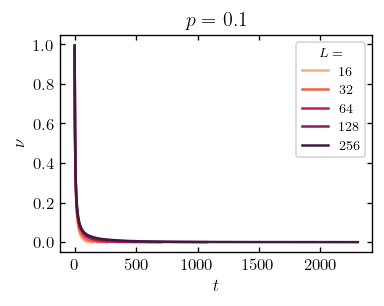

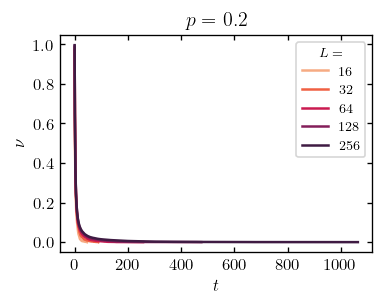

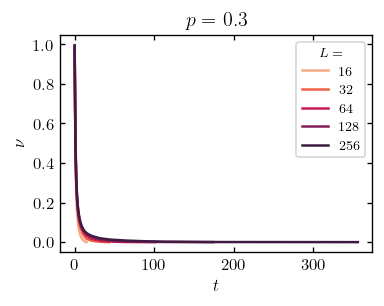

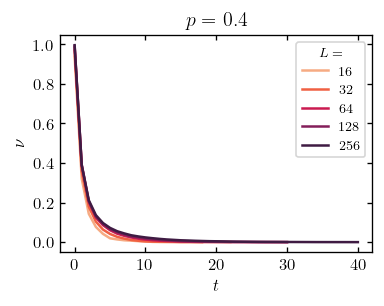

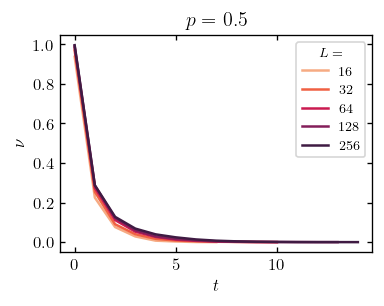

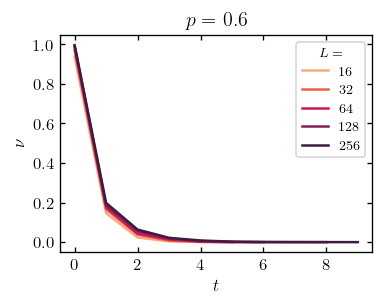

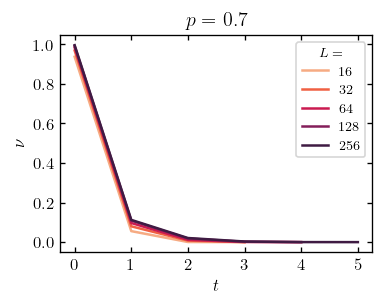

In [60]:
for jj, p in enumerate(p_list):
    color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


    fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in')
    for ii, L in enumerate(L_list):
        ax.plot(np.arange(len(nullity_evolution[ii][jj])), nullity_evolution[ii][jj]/L, '-', label = rf'{L}', color = color_list[ii], markersize = 2)
    #ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
    ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
    ax.set_xlabel('$t$', fontsize=10)  # Set the xlabel size
    ax.set_ylabel(r'$\nu$', fontsize=10)  # Set the xlabel size
    ax.set_title(rf'$p=$ {p}')

    #plt.xscale('log')
    #plt.yscale('log')

    plt.show()

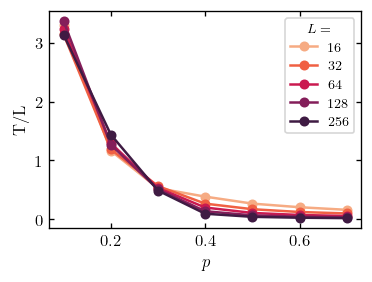

In [61]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

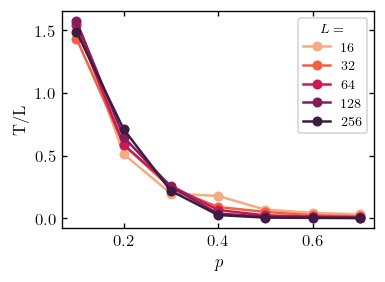

In [63]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time_variance[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

In [25]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256]
p_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
cases = 100

braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_time_std = np.zeros((len(L_list), len(p_list)))
samples = np.zeros((len(L_list), len(p_list)))

for ii, L in enumerate(L_list):

    for jj, p in enumerate(p_list):
        
        lengths = []
        times_list = []
        values = []
        count = 0
        for case in range(cases):
            filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results_singleT_p'+str("%.2f"%p)+f'_L{L}_init_state_random_case{case}.pkl'
            with open(filename, 'rb') as f:
                times = pickle.load(f)
                
            lengths.append(len(times))
            times_list.append(times)

        minlen = min(lengths)
        for times in times_list:
            values += times[:minlen]

        braidification_time_std[ii,jj] = np.std(values)
        braidification_time[ii,jj] = np.mean(values)
        samples[ii,jj] = len(values)

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['braidification_time_std'] = braidification_time_std  
data['braidification_time'] = braidification_time  
data['samples'] = samples  


filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results_singleT.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

In [14]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle//results_singleT.pkl'

with open(filename, 'rb') as f:
    data = pickle.load(f)

L_list = data['L_list']
p_list = data['p_list']

braidification_time = data['braidification_time']  
braidification_time_std = data['braidification_time_std']  

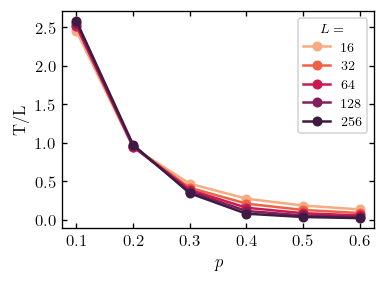

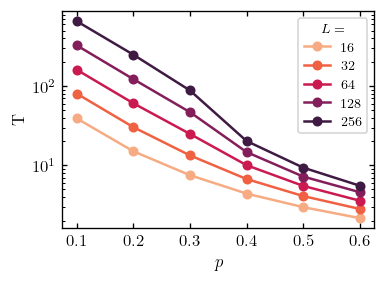

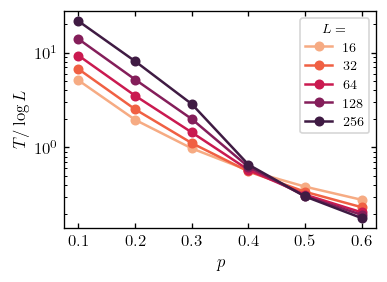

In [8]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii], '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/np.log(L)**2, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$T/\log L$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()

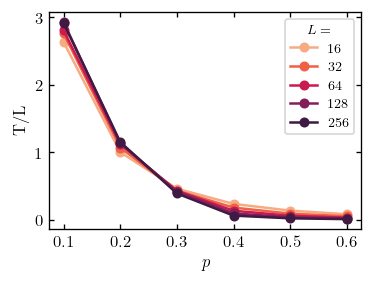

In [6]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time_std[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

In [28]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256]
p_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
cases = 100

braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_time_std = np.zeros((len(L_list), len(p_list)))
samples = np.zeros((len(L_list), len(p_list)))
all_samples = []

for ii, L in enumerate(L_list):
    all_samples.append([])
    
    for jj, p in enumerate(p_list):
        all_samples[ii].append([])

        lengths = []
        times_list = []
        values = []
        count = 0
        
        filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}.pkl'
        with open(filename, 'rb') as f:
            values = pickle.load(f)

        
        all_samples[ii][jj].append(values)
    
            
        braidification_time_std[ii,jj] = np.std(values)
        braidification_time[ii,jj] = np.mean(values)
        samples[ii,jj] = len(values)

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['braidification_time_std'] = braidification_time_std  
data['braidification_time'] = braidification_time  
data['samples'] = samples  


filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

In [67]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT.pkl'

with open(filename, 'rb') as f:
    data = pickle.load(f)

L_list = data['L_list']
p_list = data['p_list']

braidification_time = data['braidification_time']  
braidification_time_std = data['braidification_time_std']  

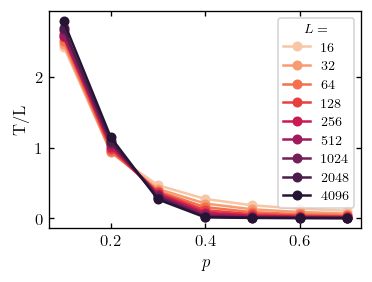

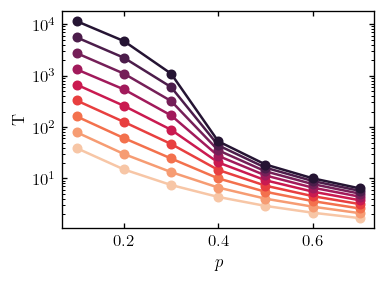

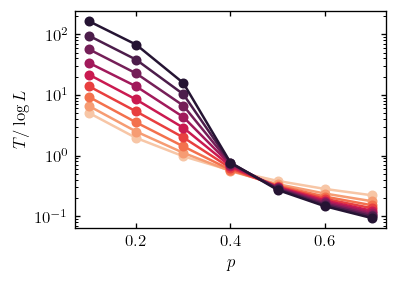

In [69]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii], '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
#ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/np.log(L)**2, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
#ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$T/\log L$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()

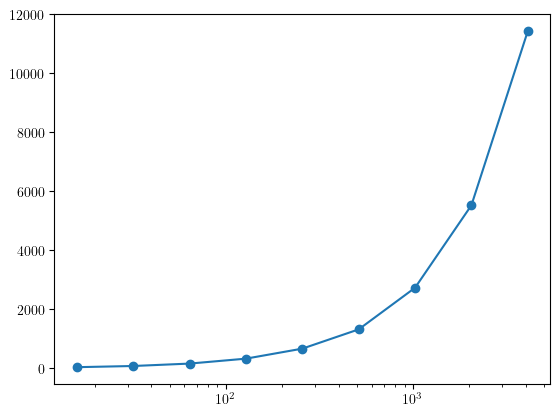

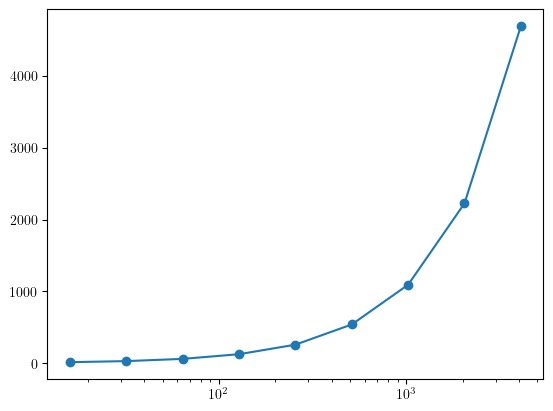

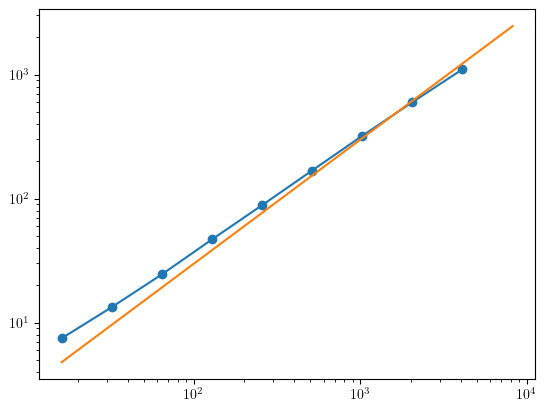

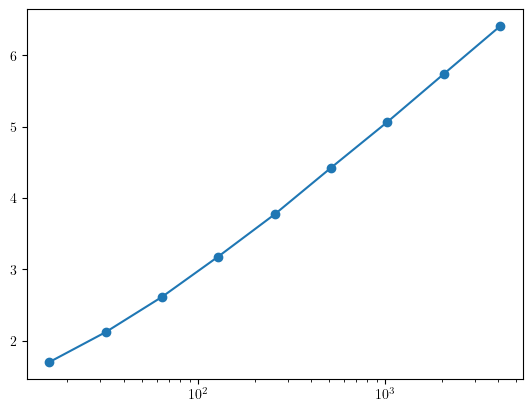

In [17]:
plt.plot(L_list, braidification_time[:, 0], '-o')
#plt.plot(np.arange(16, 8200), 2.5*np.arange(16, 8200))
plt.xscale('log')
#plt.yscale('log')
plt.show()

plt.plot(L_list, braidification_time[:, 1], '-o')
#plt.plot(np.arange(16, 8200), 1*np.arange(16, 8200))
plt.xscale('log')
#plt.yscale('log')
plt.show()

plt.plot(L_list, braidification_time[:, 2], '-o')
plt.plot(np.arange(16, 8200), 0.3*np.arange(16, 8200))
plt.xscale('log')
plt.yscale('log')
plt.show()

plt.plot(L_list, braidification_time[:,-1], '-o')
plt.xscale('log')
#plt.yscale('log')
plt.show()

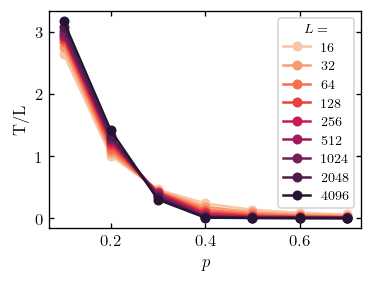

In [18]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time_std[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

In [50]:
samples

array([[100000., 100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000., 100000.],
       [ 10000.,  10000., 100000., 100000., 100000., 100000., 100000.],
       [ 10000.,  10000., 100000., 100000., 100000., 100000., 100000.],
       [ 10000.,  10000., 100000., 100000., 100000., 100000., 100000.],
       [ 10000.,  10000., 100000., 100000., 100000., 100000., 100000.],
       [ 10000.,  10000., 100000., 100000., 100000., 100000., 100000.]])

16 0.1
32 0.1
64 0.1
128 0.1
256 0.1
512 0.1
1024 0.1
2048 0.1
4096 0.1


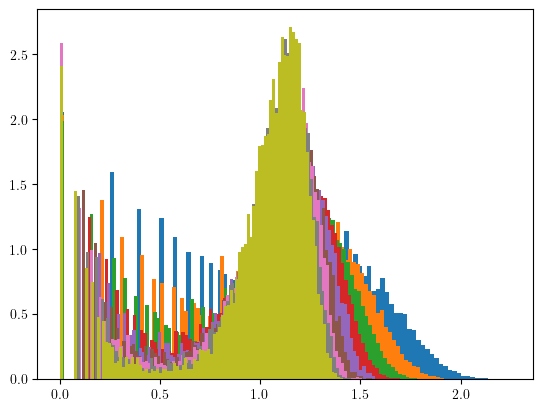

16 0.2
32 0.2
64 0.2
128 0.2
256 0.2
512 0.2
1024 0.2
2048 0.2
4096 0.2


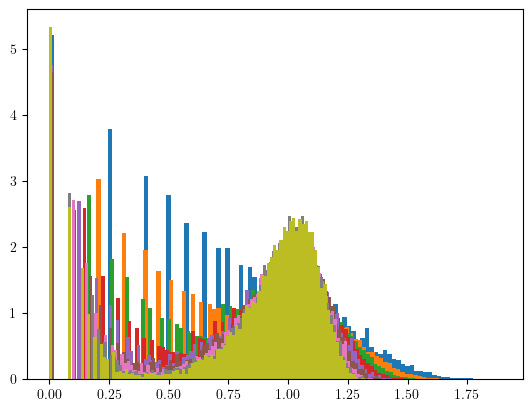

16 0.3
32 0.3
64 0.3
128 0.3
256 0.3
512 0.3
1024 0.3
2048 0.3
4096 0.3


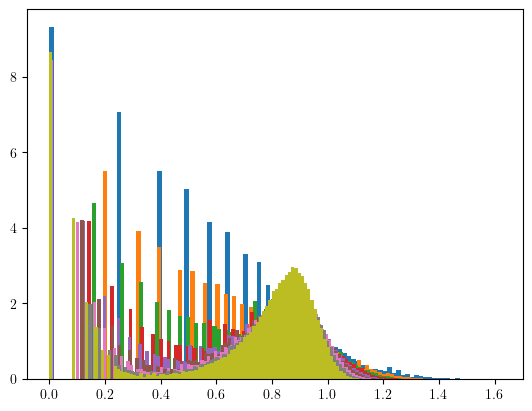

16 0.4
32 0.4
64 0.4
128 0.4
256 0.4
512 0.4
1024 0.4
2048 0.4
4096 0.4


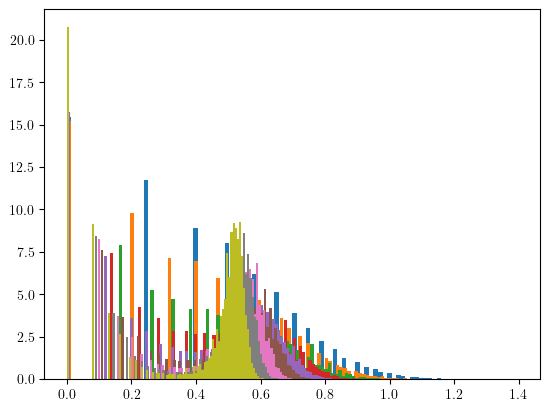

16 0.5
32 0.5
64 0.5
128 0.5
256 0.5
512 0.5
1024 0.5
2048 0.5
4096 0.5


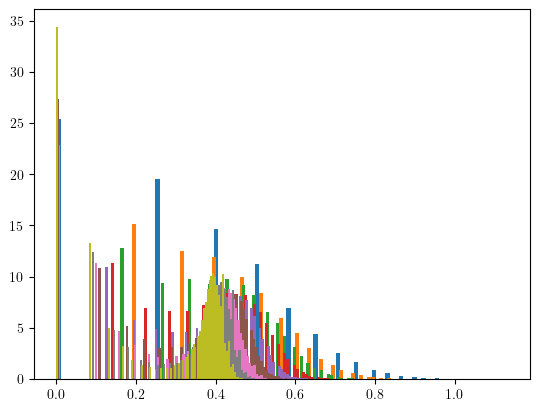

16 0.6
32 0.6
64 0.6
128 0.6
256 0.6
512 0.6
1024 0.6
2048 0.6
4096 0.6


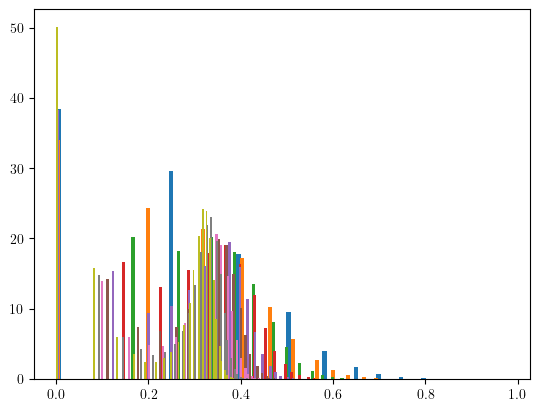

16 0.7
32 0.7
64 0.7
128 0.7
256 0.7
512 0.7
1024 0.7
2048 0.7
4096 0.7


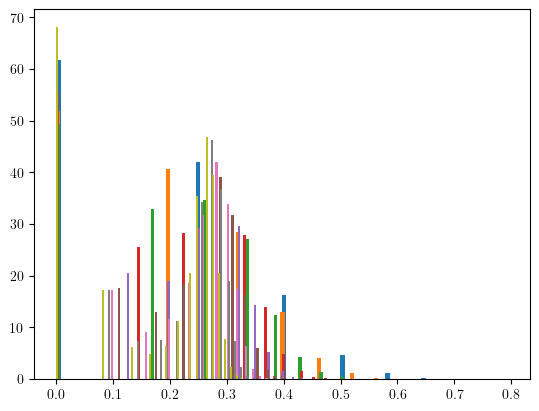

In [57]:
for jj, p in enumerate(p_list):
    for ii, L in enumerate(L_list):
        print(L, p)
        data = np.array(all_samples[ii][jj])
        data = data[data != 0]
        plt.hist(np.log(data)/np.log(L), 100, density = True)
        
    plt.show()

In [15]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 8192*2, 8192*4]
p_list = [0.5, 0.6, 0.7, 0.8, 0.9]
cases = 100

braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_time_std = np.zeros((len(L_list), len(p_list)))
samples = np.zeros((len(L_list), len(p_list)))
all_samples = np.zeros((len(L_list), len(p_list), 100000))

for ii, L in enumerate(L_list):

    for jj, p in enumerate(p_list):
        
        lengths = []
        times_list = []
        values = []
        count = 0
        
        filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}.pkl'
        with open(filename, 'rb') as f:
            values = pickle.load(f)

        
        
    
            
        braidification_time_std[ii,jj] = np.std(values)
        braidification_time[ii,jj] = np.mean(values)
        samples[ii,jj] = len(values)
        all_samples[ii,jj] = np.array(values)
     
    
data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['braidification_time_std'] = braidification_time_std  
data['braidification_time'] = braidification_time  
data['samples'] = samples  
data['all_samples'] = all_samples  


filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)          


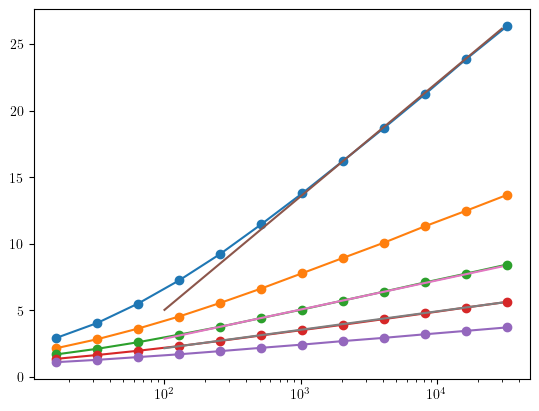

In [24]:
for jj, p in enumerate(p_list):
    plt.plot(L_list, braidification_time[:,jj], '-o')
plt.xscale('log')
#plt.yscale('log')
plt.plot(np.linspace(100,3e4), 3.7*np.log(np.linspace(100,3e4))-12)
plt.plot(np.linspace(100,3e4), 0.95*np.log(np.linspace(100,3e4))-1.5)
plt.plot(np.linspace(100,3e4), 0.6*np.log(np.linspace(100,3e4))-0.6)

plt.show()

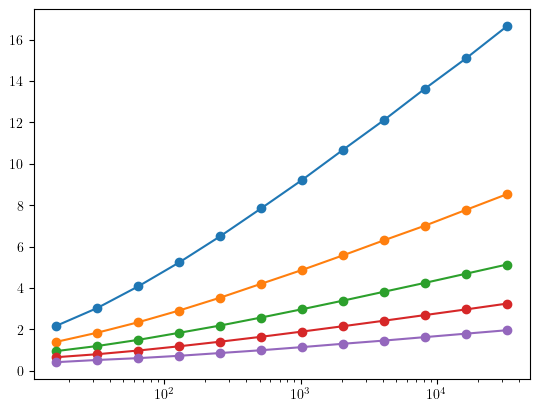

In [25]:
for jj, p in enumerate(p_list):
    plt.plot(L_list, braidification_time_std[:,jj], '-o')
plt.xscale('log')
#plt.yscale('log')

plt.show()

16 0.5
32 0.5
64 0.5
128 0.5
256 0.5
512 0.5
1024 0.5
2048 0.5
4096 0.5
8192 0.5
16384 0.5
32768 0.5


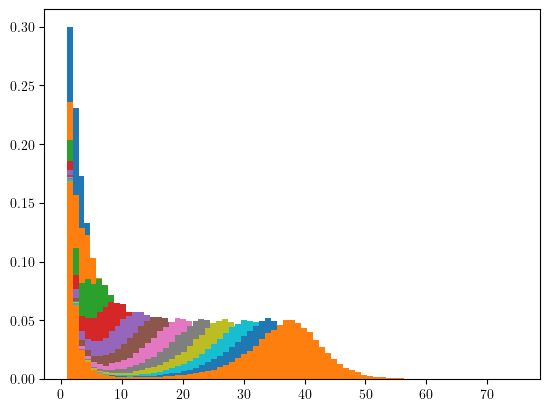

16 0.6
32 0.6
64 0.6
128 0.6
256 0.6
512 0.6
1024 0.6
2048 0.6
4096 0.6
8192 0.6
16384 0.6
32768 0.6


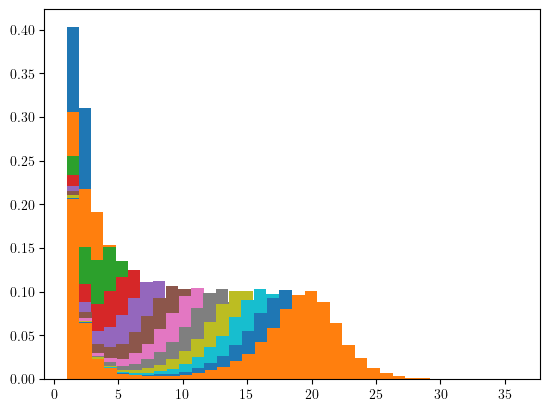

16 0.7
32 0.7
64 0.7
128 0.7
256 0.7
512 0.7
1024 0.7
2048 0.7
4096 0.7
8192 0.7
16384 0.7
32768 0.7


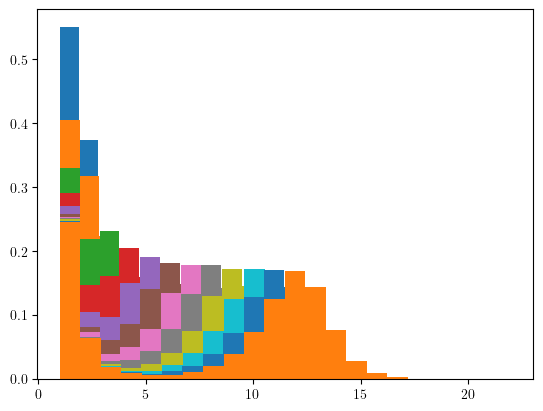

16 0.8
32 0.8
64 0.8
128 0.8
256 0.8
512 0.8
1024 0.8
2048 0.8
4096 0.8
8192 0.8
16384 0.8
32768 0.8


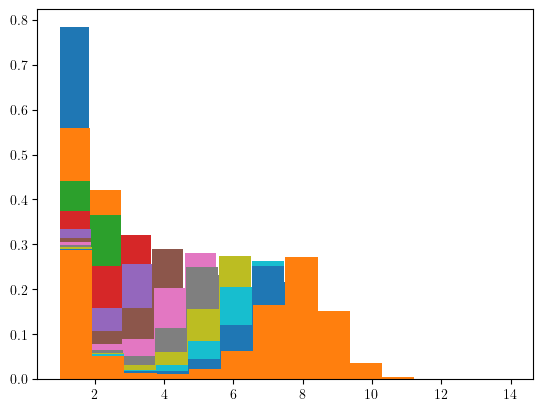

16 0.9
32 0.9
64 0.9
128 0.9
256 0.9
512 0.9
1024 0.9
2048 0.9
4096 0.9
8192 0.9
16384 0.9
32768 0.9


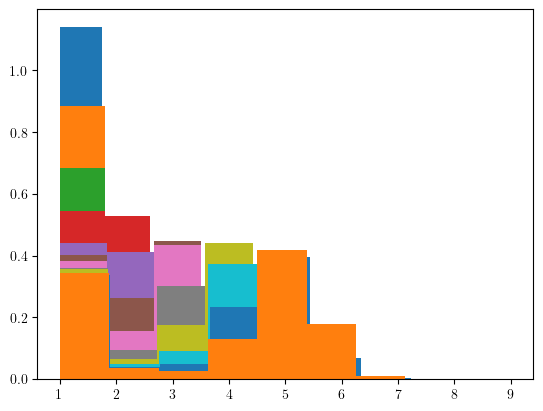

In [17]:
for jj, p in enumerate(p_list):
    for ii, L in enumerate(L_list):
        print(L, p)
        data = all_samples[ii, jj]
        data = data[data != 0]
        plt.hist(data, int(np.max(data)), density = True)
        
    plt.show()

In [8]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
p_list = [0.3, 0.32, 0.34, 0.36, 0.38, 0.4]

braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_time_std = np.zeros((len(L_list), len(p_list)))
samples = np.zeros((len(L_list), len(p_list)))
all_samples = np.zeros((len(L_list), len(p_list), 100000), int)
for ii, L in enumerate(L_list):

    for jj, p in enumerate(p_list):
        
        lengths = []
        times_list = []
        values = []
        count = 0

        filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}.pkl'
        with open(filename, 'rb') as f:
            values = pickle.load(f)
        braidification_time_std[ii,jj] = np.std(values)
        braidification_time[ii,jj] = np.mean(values)
        samples[ii,jj] = len(values)
        all_samples[ii,jj] = np.array(values)


        

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['braidification_time_std'] = braidification_time_std  
data['braidification_time'] = braidification_time  
data['samples'] = samples  
data['all_samples'] = all_samples  


filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

In [9]:
samples

array([[100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.],
       [100000., 100000., 100000., 100000., 100000., 100000.]])

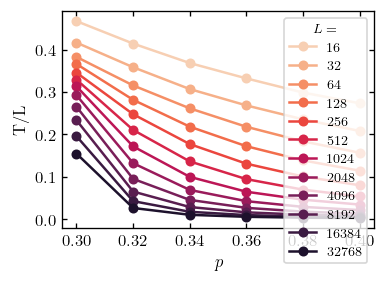

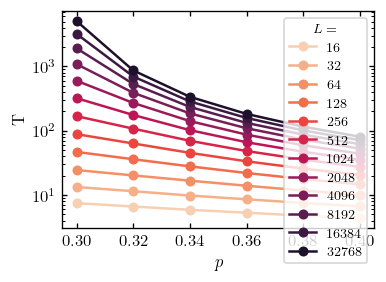

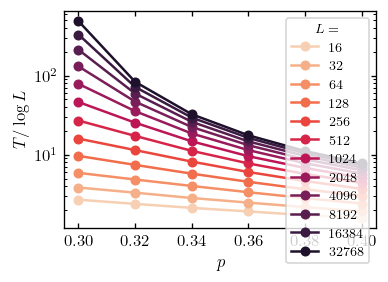

In [62]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/L, '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T/L', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii], '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'T', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()

color_list = sns.color_palette('rocket_r', n_colors = len(L_list))

fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, braidification_time[ii]/np.log(L), '-o', label = rf'{L}', color = color_list[ii], markersize = 5)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$T/\log L$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
plt.yscale('log')

plt.show()



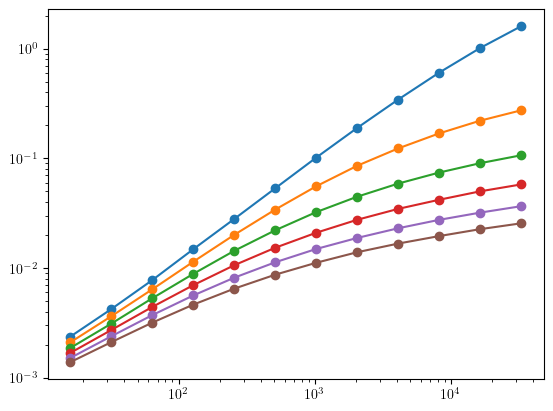

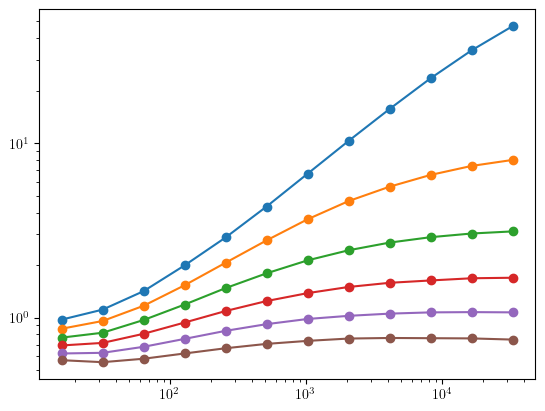

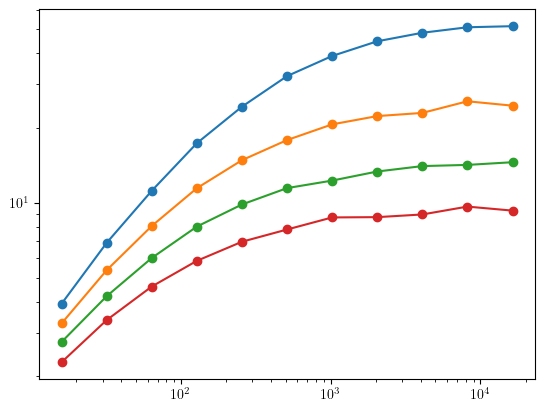

In [58]:
for jj, p in enumerate(p_list):
    plt.plot(L_list, braidification_time[:,jj], '-o')
plt.xscale('log')
plt.yscale('log')

plt.show()


for jj, p in enumerate(p_list):
    plt.plot(L_list, braidification_time[:,jj]/np.log(np.array(L_list))**2, '-o')
plt.xscale('log')
plt.yscale('log')

plt.show()

for jj, p in enumerate(p_list):
    if p > 0.32:
        plt.plot(L_list[:-1], braidification_time[1:,jj]-braidification_time[:-1,jj], '-o')
plt.xscale('log')
plt.yscale('log')

plt.show()

16 0.3
32 0.3
64 0.3
128 0.3
256 0.3
512 0.3
1024 0.3
2048 0.3
4096 0.3
8192 0.3
16384 0.3
32768 0.3


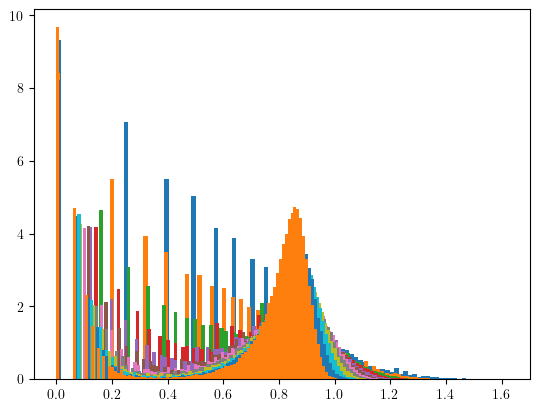

16 0.32
32 0.32
64 0.32
128 0.32
256 0.32
512 0.32
1024 0.32
2048 0.32
4096 0.32
8192 0.32
16384 0.32
32768 0.32


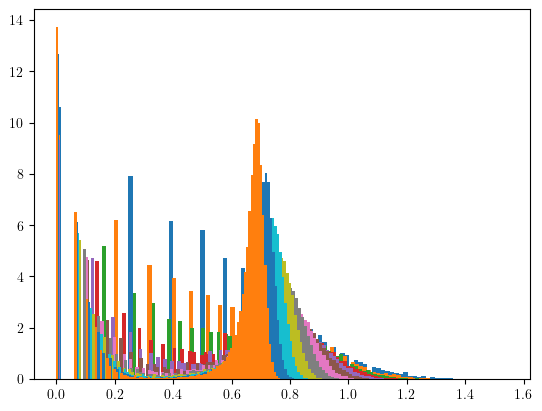

16 0.34
32 0.34
64 0.34
128 0.34
256 0.34
512 0.34
1024 0.34
2048 0.34
4096 0.34
8192 0.34
16384 0.34
32768 0.34


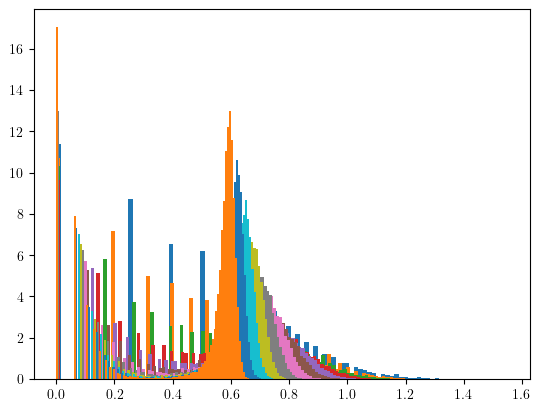

16 0.36
32 0.36
64 0.36
128 0.36
256 0.36
512 0.36
1024 0.36
2048 0.36
4096 0.36
8192 0.36
16384 0.36
32768 0.36


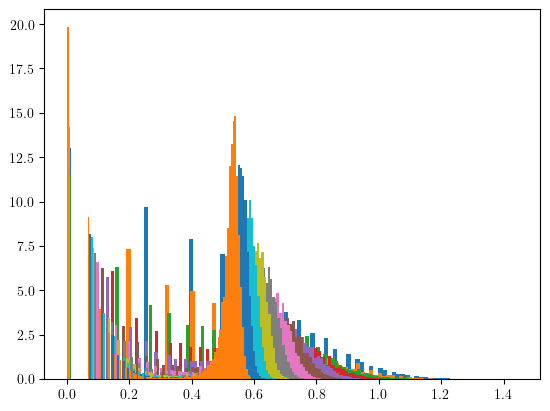

16 0.38
32 0.38
64 0.38
128 0.38
256 0.38
512 0.38
1024 0.38
2048 0.38
4096 0.38
8192 0.38
16384 0.38
32768 0.38


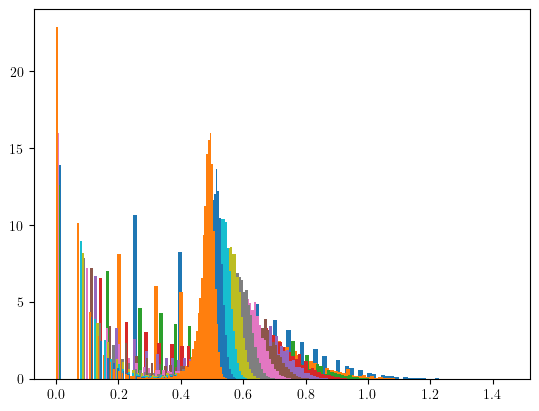

16 0.4
32 0.4
64 0.4
128 0.4
256 0.4
512 0.4
1024 0.4
2048 0.4
4096 0.4
8192 0.4
16384 0.4
32768 0.4


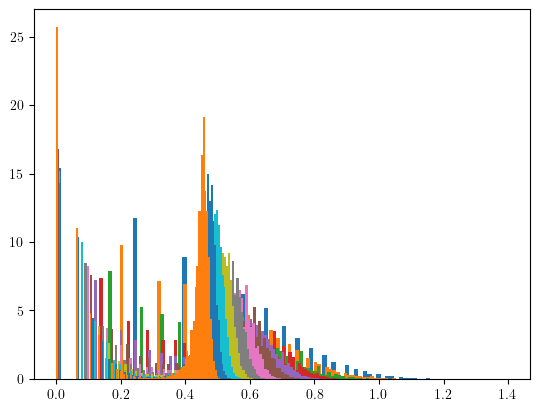

In [14]:
for jj, p in enumerate(p_list):
    for ii, L in enumerate(L_list):
        print(L, p)
        data = all_samples[ii, jj]
        data = data[data != 0]
        plt.hist(np.log(data)/np.log(L), 100, density = True)
    plt.show()

16 0.36
32 0.36
64 0.36
128 0.36
256 0.36
512 0.36
1024 0.36
2048 0.36
4096 0.36
8192 0.36
16384 0.36
32768 0.36


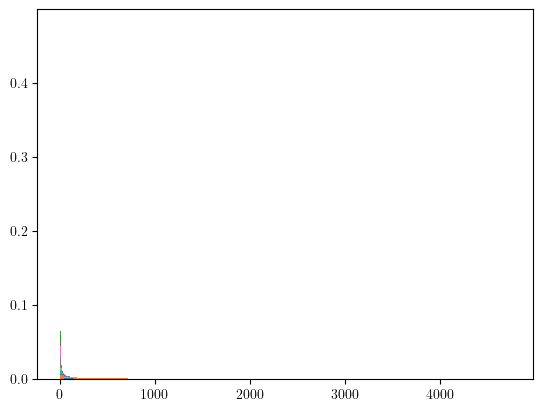

16 0.38
32 0.38
64 0.38
128 0.38
256 0.38
512 0.38
1024 0.38
2048 0.38
4096 0.38
8192 0.38
16384 0.38
32768 0.38


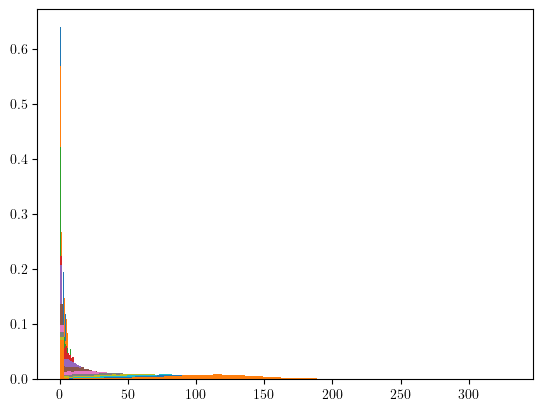

16 0.4
32 0.4
64 0.4
128 0.4
256 0.4
512 0.4
1024 0.4
2048 0.4
4096 0.4
8192 0.4
16384 0.4
32768 0.4


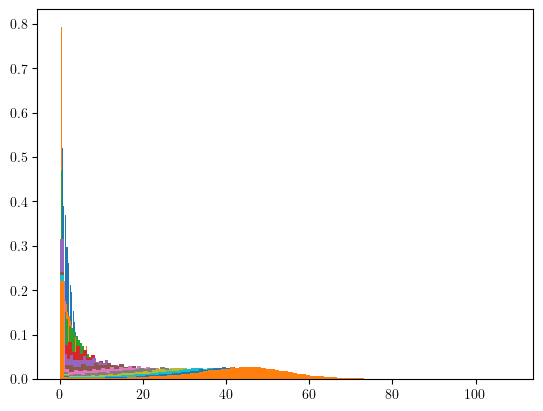

In [22]:
for jj, p in enumerate(p_list[3:]):
    for ii, L in enumerate(L_list):
        print(L, p)
        data = all_samples[ii, jj]
        data = data[data != 0]
        plt.hist(data/np.log(L), 100, density = True)
    plt.show()

In [35]:
print(np.log(all_samples[0,0,:1000]))

[1.60943791 3.36729583 0.         2.19722458 2.48490665 1.38629436
 2.94443898 1.09861229 0.         0.         1.09861229 0.69314718
 0.69314718 0.         1.38629436 0.         0.69314718 0.
 1.38629436 1.09861229 2.56494936 2.94443898 1.79175947 2.30258509
 1.94591015 2.30258509 2.07944154 2.30258509 1.60943791 1.79175947
 0.         0.         2.48490665 2.48490665 1.38629436 1.09861229
 2.30258509 0.         1.79175947 2.48490665 0.69314718 2.19722458
 2.94443898 2.07944154 2.39789527 0.         1.60943791 0.
 3.25809654 2.07944154 0.69314718 2.94443898 2.07944154 1.94591015
 1.94591015 1.09861229       -inf 0.69314718 1.60943791 2.39789527
 2.56494936 1.38629436 1.79175947 2.30258509 2.19722458 0.
 2.19722458 1.60943791 0.69314718 0.69314718 2.19722458 1.09861229
 0.         0.         3.09104245 1.79175947 0.         0.
 1.60943791 2.07944154 2.30258509 1.94591015 2.07944154       -inf
 2.89037176 0.         1.38629436 1.94591015 0.69314718 1.94591015
 0.69314718 1.38629436 0.69

/tmp/ipykernel_503783/2953582834.py:1: RuntimeWarning: divide by zero encountered in log
  print(np.log(all_samples[0,0,:1000]))


In [7]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [8192*4] 
p_list = [0.4]
cases = 1000

braidification_time = np.zeros((len(L_list), len(p_list)))
braidification_time_std = np.zeros((len(L_list), len(p_list)))
samples = np.zeros((len(L_list), len(p_list)))

for ii, L in enumerate(L_list):

    for jj, p in enumerate(p_list):
        
        lengths = []
        times_list = []
        values = []
        count = 0
        
        for case in range(cases):
            filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}_init_state_random_case{case}.pkl'
            with open(filename, 'rb') as f:
                times = pickle.load(f)

            lengths.append(len(times))
            times_list.append(times)    
            os.remove(filename)
        
        
        minlen = min(lengths)
        for times in times_list:
            values += times[:minlen]

        filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}.pkl'
        with open(filename, 'wb') as f:
            pickle.dump(values, f, pickle.HIGHEST_PROTOCOL)   

        braidification_time_std[ii,jj] = np.std(values)
        braidification_time[ii,jj] = np.mean(values)
        samples[ii,jj] = len(values)
#        except:
#            filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}.pkl'
#            with open(filename, 'rb') as f:
#                values = pickle.load(f)
#            braidification_time_std[ii,jj] = np.std(values)
#            braidification_time[ii,jj] = np.mean(values)
#            samples[ii,jj] = len(values)




#filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT.pkl'
    
#with open(filename, 'wb') as f:
#    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  


In [19]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p0.30_L16384_init_state_random_case0.pkl'
with open(filename, 'rb') as f:
    values = pickle.load(f)  


FileNotFoundError: [Errno 2] No such file or directory: '/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p0.30_L16384_init_state_random_case0.pkl'

In [5]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p0.36_L{8192*4}.pkl'
with open(filename, 'rb') as f:
    values = pickle.load(f)   

FileNotFoundError: [Errno 2] No such file or directory: '/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p0.36_L32768.pkl'

In [13]:
list_dict = []

L_list = [8192*4]

p_list = [0.3]
cases = [278, 339, 814, 815, 816, 903]


for ii, L in enumerate(L_list):
    for jj, p in enumerate(p_list):

        reps = 100
        for case in cases:
            list_dict.append({'L': L, 'p': p, 'case': case, 'reps': reps})

L_list = [8192*4] 
p_list = [0.32, 0.34, 0.36]
cases = 1000

import pickle

for ii, L in enumerate(L_list):

    for jj, p in enumerate(p_list):
        
        
        for case in range(cases):
            try:
                filename = f'/space/ge24yov/gaussian_nonstabilizerness_disentangle_classical//results_singleT_p'+str("%.2f"%p)+f'_L{L}_init_state_random_case{case}.pkl'
                with open(filename, 'rb') as f:
                    times = pickle.load(f)
    
                lengths.append(len(times))
                if len(times)<100:
                    list_dict.append({'L': L, 'p': p, 'case': case, 'reps': 100})
            except:
                list_dict.append({'L': L, 'p': p, 'case': case, 'reps': 100})


print(len(list_dict))

1668
